In [ ]:
import time
import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE

try:
    from tensorflow.keras.datasets import fashion_mnist
except ImportError:
    raise ImportError("Install tensorflow first using: pip install tensorflow")

In [ ]:
print("\nPART A: DATA LOADING AND PREPARATION")
print("-" * 70)
(X_train, y_train), (X_test, y_test) = fashion_mnist.load_data()
print("Training data shape :", X_train.shape)
print("Training labels shape:", y_train.shape)
print("Test data shape     :", X_test.shape)
print("Test labels shape   :", y_test.shape)


PART A: DATA LOADING AND PREPARATION
----------------------------------------------------------------------
29515/29515 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
26421880/26421880 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
5148/5148 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
4422102/4422102 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Training data shape : (60000, 28, 28)
Training labels shape: (60000,)
Test data shape     : (10000, 28, 28)
Test labels shape   : (10000,)


In [ ]:
X_train = X_train.astype("float32") / 255.0
X_test = X_test.astype("float32") / 255.0
class_names = [
    "T-shirt/top", "Trouser", "Pullover", "Dress", "Coat",
    "Sandal", "Shirt", "Sneaker", "Bag", "Ankle boot"
]
print("\nDataset Statistics:")
print("Min pixel value :", X_train.min())
print("Max pixel value :", X_train.max())
print("Mean pixel value:", X_train.mean())
print("Std pixel value :", X_train.std())


Dataset Statistics:
Min pixel value : 0.0
Max pixel value : 1.0
Mean pixel value: 0.2860402
Std pixel value : 0.3530239



Class distribution:
0 - T-shirt/top : 6000
1 - Trouser     : 6000
2 - Pullover    : 6000
3 - Dress       : 6000
4 - Coat        : 6000
5 - Sandal      : 6000
6 - Shirt       : 6000
7 - Sneaker     : 6000
8 - Bag         : 6000
9 - Ankle boot  : 6000


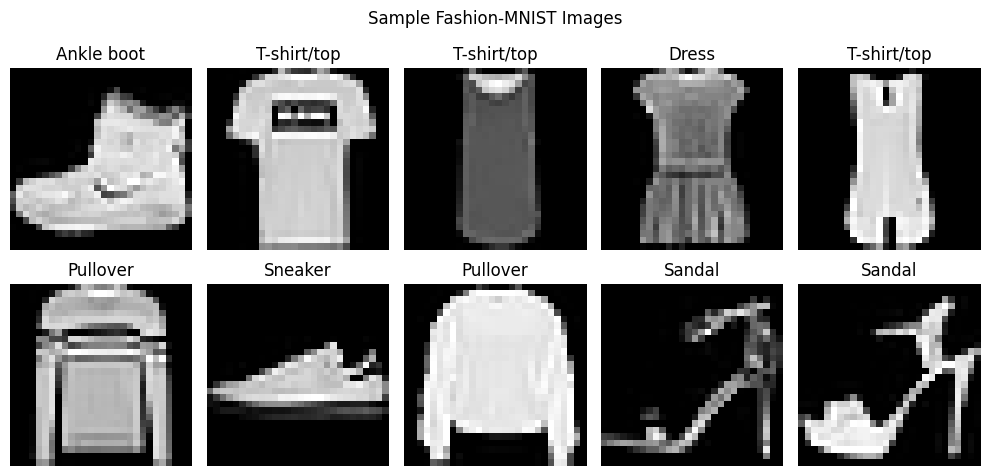


Using 3000 samples for PCA and t-SNE


In [ ]:
unique, counts = np.unique(y_train, return_counts=True)
print("\nClass distribution:")
for u, c in zip(unique, counts):
    print(f"{u} - {class_names[u]:12s}: {c}")
plt.figure(figsize=(10, 5))
for i in range(10):
    plt.subplot(2, 5, i + 1)
    plt.imshow(X_train[i], cmap="gray")
    plt.title(class_names[y_train[i]])
    plt.axis("off")
plt.suptitle("Sample Fashion-MNIST Images")
plt.tight_layout()
plt.show()
X_flat = X_train.reshape(X_train.shape[0], -1)
sample_size = 3000
X_sample = X_flat[:sample_size]
y_sample = y_train[:sample_size]
print(f"\nUsing {sample_size} samples for PCA and t-SNE")


PART B: PCA IMPLEMENTATION
----------------------------------------------------------------------


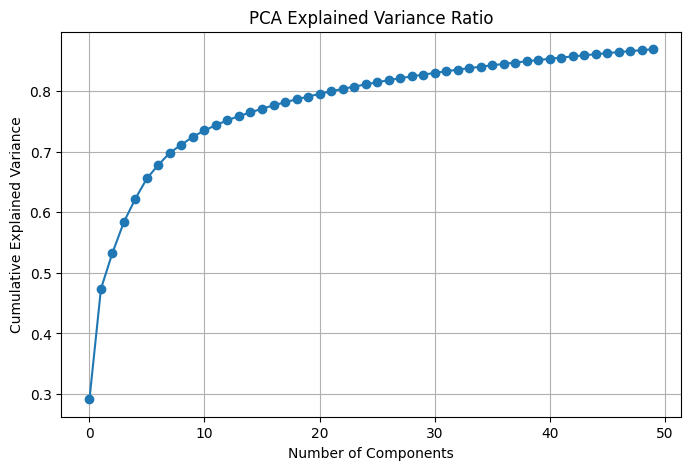

In [ ]:
print("\nPART B: PCA IMPLEMENTATION")
print("-" * 70)
pca_full = PCA()
pca_full.fit(X_sample)
explained_variance = pca_full.explained_variance_ratio_
plt.figure(figsize=(8, 5))
plt.plot(np.cumsum(explained_variance[:50]), marker='o')
plt.xlabel("Number of Components")
plt.ylabel("Cumulative Explained Variance")
plt.title("PCA Explained Variance Ratio")
plt.grid(True)
plt.show()

PCA completed in 0.1438 seconds
Explained variance by 2 components: [0.29132396 0.18239403]
Total explained variance: 0.473718


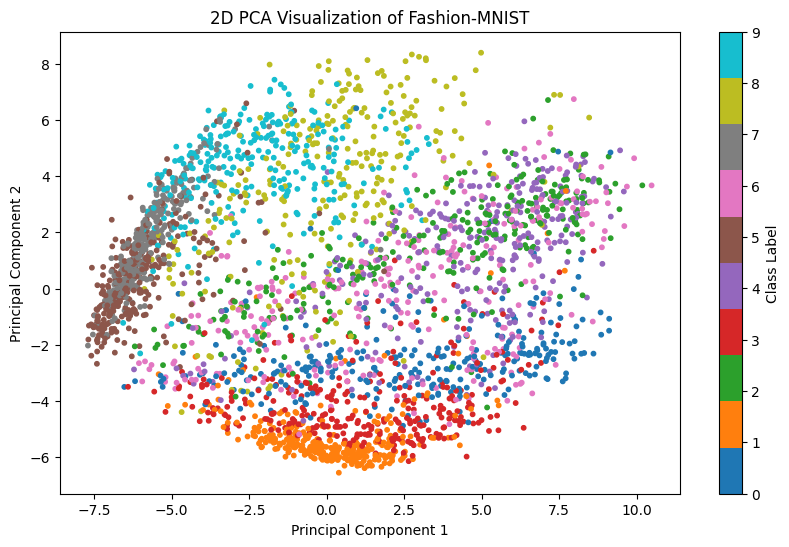

In [ ]:
pca_2d = PCA(n_components=2)
start_pca = time.time()
X_pca = pca_2d.fit_transform(X_sample)
pca_time = time.time() - start_pca
print(f"PCA completed in {pca_time:.4f} seconds")
print("Explained variance by 2 components:", pca_2d.explained_variance_ratio_)
print("Total explained variance:", np.sum(pca_2d.explained_variance_ratio_))
plt.figure(figsize=(10, 6))
scatter = plt.scatter(X_pca[:, 0], X_pca[:, 1], c=y_sample, cmap="tab10", s=10)
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.title("2D PCA Visualization of Fashion-MNIST")
plt.colorbar(scatter, ticks=range(10), label="Class Label")
plt.show()


PART C: t-SNE IMPLEMENTATION
----------------------------------------------------------------------

Running t-SNE with perplexity = 5 ...
t-SNE with perplexity 5 completed in 22.5964 seconds


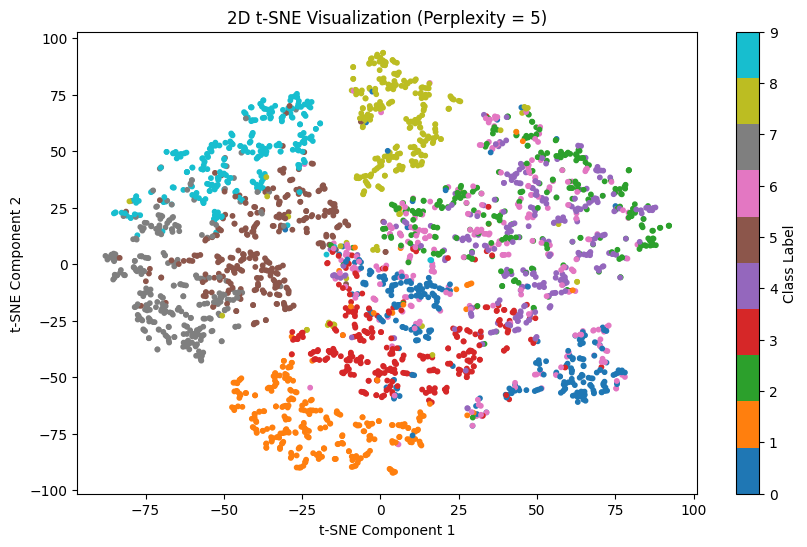


Running t-SNE with perplexity = 30 ...
t-SNE with perplexity 30 completed in 27.9203 seconds


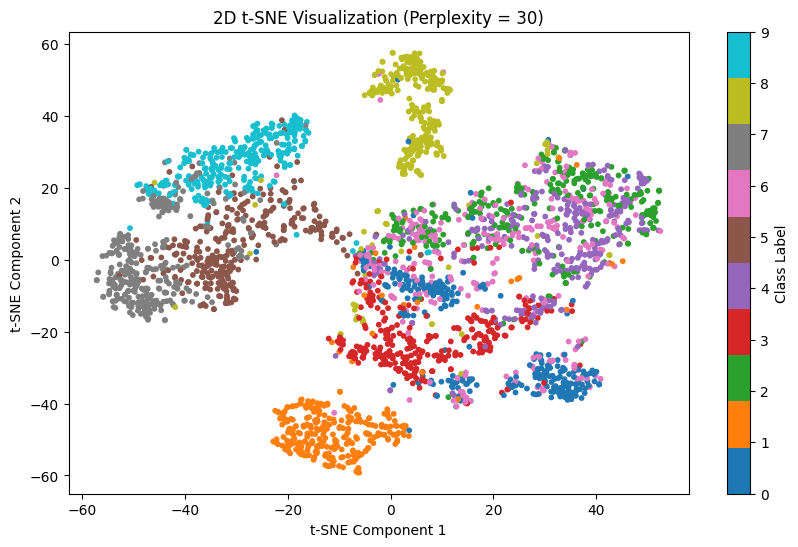


Running t-SNE with perplexity = 50 ...
t-SNE with perplexity 50 completed in 31.5460 seconds


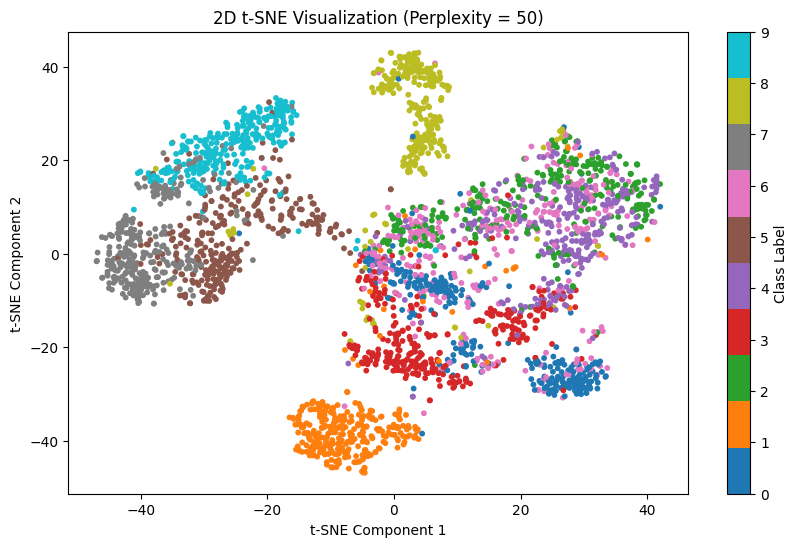

In [ ]:
print("\nPART C: t-SNE IMPLEMENTATION")
print("-" * 70)
perplexities = [5, 30, 50]
tsne_results = {}
tsne_times = {}
for p in perplexities:
    print(f"\nRunning t-SNE with perplexity = {p} ...")
    tsne = TSNE(n_components=2, perplexity=p, random_state=42, init="pca", learning_rate="auto")
    start_tsne = time.time()
    X_tsne = tsne.fit_transform(X_sample)
    tsne_time = time.time() - start_tsne
    tsne_results[p] = X_tsne
    tsne_times[p] = tsne_time
    print(f"t-SNE with perplexity {p} completed in {tsne_time:.4f} seconds")
    plt.figure(figsize=(10, 6))
    scatter = plt.scatter(X_tsne[:, 0], X_tsne[:, 1], c=y_sample, cmap="tab10", s=10)
    plt.xlabel("t-SNE Component 1")
    plt.ylabel("t-SNE Component 2")
    plt.title(f"2D t-SNE Visualization (Perplexity = {p})")
    plt.colorbar(scatter, ticks=range(10), label="Class Label")
    plt.show()

In [9]:
print("\nPART D: COMPARISON AND ANALYSIS")
print("-" * 70)

print(f"\nPCA computation time  : {pca_time:.4f} seconds")
for p in perplexities:
    print(f"t-SNE time (p={p})    : {tsne_times[p]:.4f} seconds")

print("\nAnalysis:")
print("1. PCA is much faster than t-SNE.")
print("2. PCA preserves global variance but may not clearly separate classes.")
print("3. t-SNE usually gives better local cluster separation.")
print("4. Classes like Bag, Sneaker, and Ankle boot are often better separated.")
print("5. Classes like Shirt, T-shirt/top, Pullover, and Coat may overlap more.")

print("\nLimitations:")
print("PCA Limitations:")
print("- Linear method, so it cannot capture complex non-linear patterns.")
print("- Often gives weaker visual cluster separation.")

print("\nt-SNE Limitations:")
print("- Computationally expensive and slower.")
print("- Sensitive to perplexity and random initialization.")
print("- Preserves local structure better than global structure.")
print("- Distances between far clusters may not be meaningful.")

print("\nConclusion:")
print("PCA is good for fast dimensionality reduction and overview.")
print("t-SNE is better for visualization and class separation, but slower.")


PART D: COMPARISON AND ANALYSIS
----------------------------------------------------------------------

PCA computation time  : 0.1438 seconds
t-SNE time (p=5)    : 22.5964 seconds
t-SNE time (p=30)    : 27.9203 seconds
t-SNE time (p=50)    : 31.5460 seconds

Analysis:
1. PCA is much faster than t-SNE.
2. PCA preserves global variance but may not clearly separate classes.
3. t-SNE usually gives better local cluster separation.
4. Classes like Bag, Sneaker, and Ankle boot are often better separated.
5. Classes like Shirt, T-shirt/top, Pullover, and Coat may overlap more.

Limitations:
PCA Limitations:
- Linear method, so it cannot capture complex non-linear patterns.
- Often gives weaker visual cluster separation.

t-SNE Limitations:
- Computationally expensive and slower.
- Sensitive to perplexity and random initialization.
- Preserves local structure better than global structure.
- Distances between far clusters may not be meaningful.

Conclusion:
PCA is good for fast dimensionality 

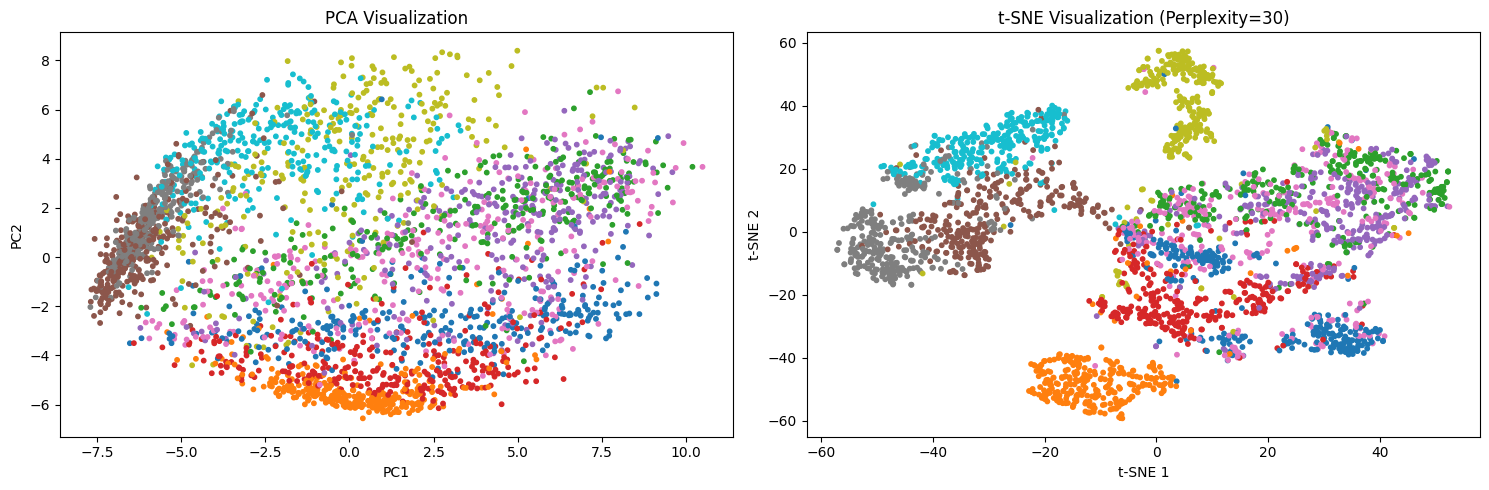

In [10]:
plt.figure(figsize=(15, 5))
plt.subplot(1, 2, 1)
plt.scatter(X_pca[:, 0], X_pca[:, 1], c=y_sample, cmap="tab10", s=10)
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("PCA Visualization")
plt.subplot(1, 2, 2)
best_p = 30
plt.scatter(tsne_results[best_p][:, 0], tsne_results[best_p][:, 1], c=y_sample, cmap="tab10", s=10)
plt.xlabel("t-SNE 1")
plt.ylabel("t-SNE 2")
plt.title(f"t-SNE Visualization (Perplexity={best_p})")
plt.tight_layout()
plt.show()